# **Term Deposit Subscription Prediction**

**Objective:** Predict whether a bank customer will subscribe to a term deposit after a marketing campaign.

## Problem Statement
Banks run phone marketing campaigns to sell term deposits. Most customers say no. If we can predict who is likely to say yes, the bank saves time and money by targeting the right people. We will train classification models and use SHAP to explain predictions.


## 1: Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score,
                             roc_curve, auc)
import shap

%matplotlib inline
print("Libraries imported.")


Libraries imported.


## 2: Load the Dataset

In [25]:
import kagglehub

# Download Bank Marketing dataset from Kaggle
path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
print("Downloaded to:", path)

# Copy all files to current working directory so pandas can find them
for f in os.listdir(path):
    shutil.copy(os.path.join(path, f), f)
    print("Copied:", f)

Using Colab cache for faster access to the 'bank-marketing' dataset.
Downloaded to: /kaggle/input/bank-marketing
Copied: bank-additional-names.txt
Copied: bank-additional-full.csv


In [26]:
print("Files available:", os.listdir('.'))

Files available: ['.config', 'bank-additional-full.csv', 'bank-additional-names.txt', 'sample_data']


In [27]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3: Dataset Understanding

In [28]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())


Shape: (41188, 21)

Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [29]:
# Target column: 'y' — did the customer subscribe? yes or no
print("Target distribution:")
print(df['y'].value_counts())
print(f"\nSubscription rate: {df['y'].value_counts(normalize=True)['yes']*100:.1f}%")


Target distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Subscription rate: 11.3%


In [30]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## 4: Exploratory Data Analysis (EDA)

/tmp/ipykernel_9509/4073794592.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', palette='Set2')


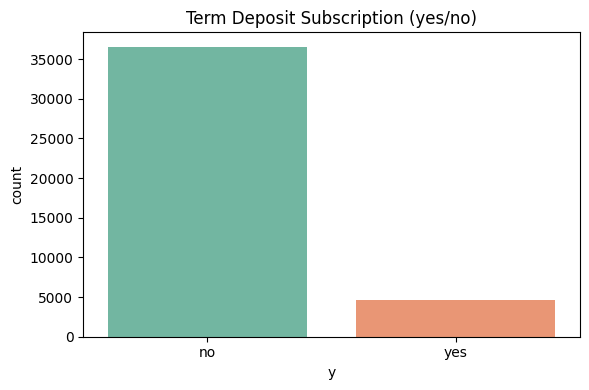

In [31]:
# Subscription count
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='y', palette='Set2')
plt.title('Term Deposit Subscription (yes/no)')
plt.tight_layout()
plt.show()


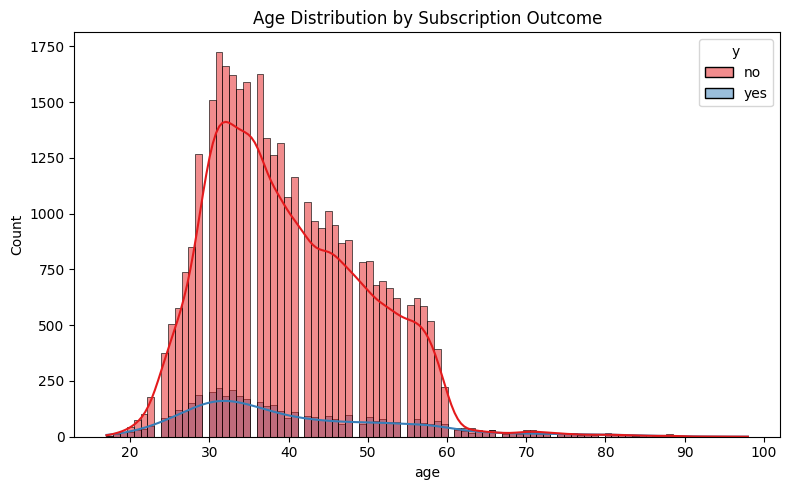

In [32]:
# Age distribution by subscription
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='y', kde=True, palette='Set1')
plt.title('Age Distribution by Subscription Outcome')
plt.tight_layout()
plt.show()


/tmp/ipykernel_9509/626559432.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_sub.index, y=job_sub.values, palette='viridis')


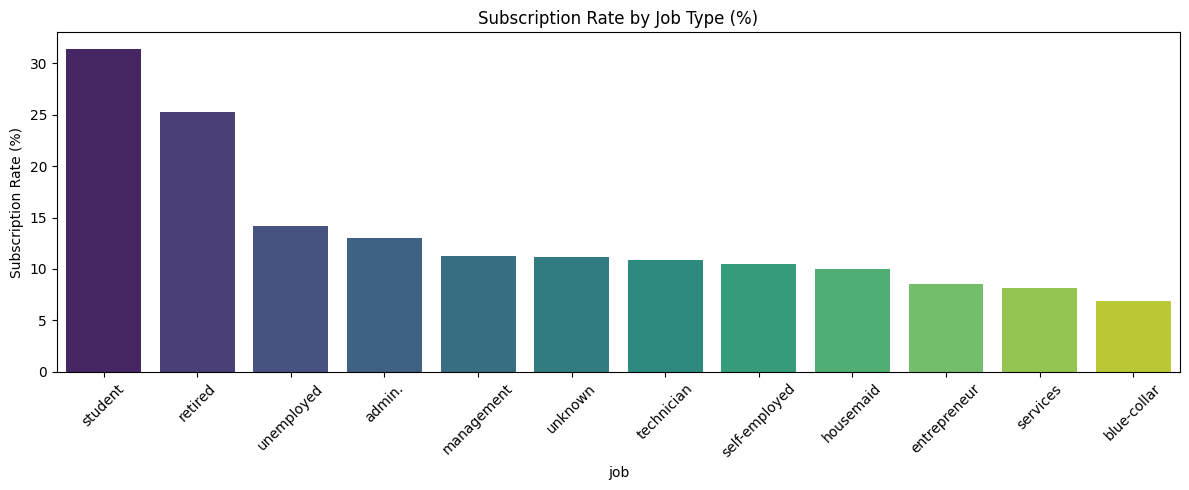

In [33]:
# Job vs subscription rate
plt.figure(figsize=(12,5))
job_sub = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean() * 100).sort_values(ascending=False)
sns.barplot(x=job_sub.index, y=job_sub.values, palette='viridis')
plt.title('Subscription Rate by Job Type (%)')
plt.xticks(rotation=45)
plt.ylabel('Subscription Rate (%)')
plt.tight_layout()
plt.show()


/tmp/ipykernel_9509/177731973.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_sub.index, y=month_sub.values, palette='coolwarm')


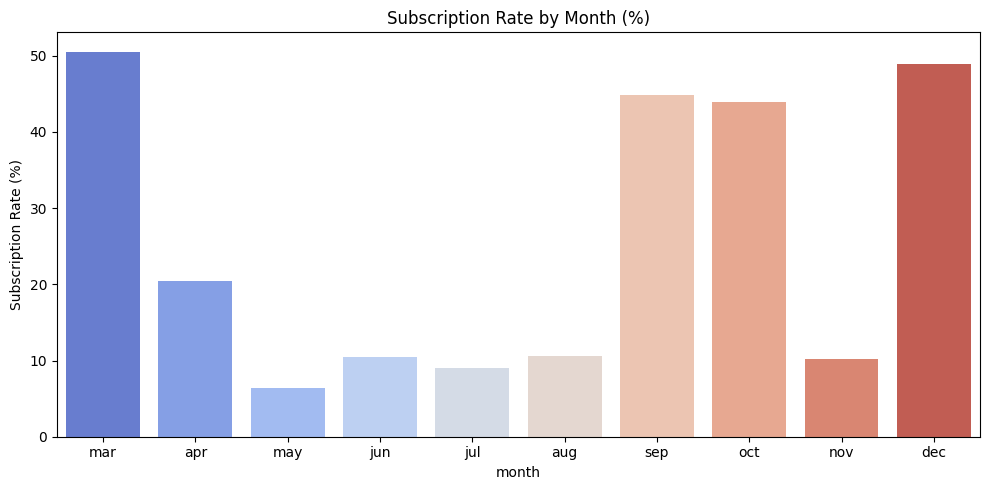

In [34]:
# Contact month vs subscription
plt.figure(figsize=(10,5))
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_sub = df.groupby('month')['y'].apply(lambda x: (x=='yes').mean()*100)
month_sub = month_sub.reindex([m for m in month_order if m in month_sub.index])
sns.barplot(x=month_sub.index, y=month_sub.values, palette='coolwarm')
plt.title('Subscription Rate by Month (%)')
plt.ylabel('Subscription Rate (%)')
plt.tight_layout()
plt.show()


## 5: Data Cleaning and Encoding

In [35]:
# Encode target column: yes=1, no=0
df['y'] = (df['y'] == 'yes').astype(int)

# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)


Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [36]:
# Label encode all categorical columns
# Each unique text value gets a unique number
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("All columns encoded.")
df.head()


All columns encoded.


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


## 6: Model Training

In [37]:
X = df.drop('y', axis=1)
y = df['y']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (32950, 20) Test: (8238, 20)


In [38]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds)
print(f"Logistic Regression — Accuracy: {lr_acc*100:.2f}%, F1: {lr_f1:.4f}")


Logistic Regression — Accuracy: 91.04%, F1: 0.5132


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
print(f"Random Forest     — Accuracy: {rf_acc*100:.2f}%, F1: {rf_f1:.4f}")


Random Forest     — Accuracy: 91.33%, F1: 0.5730


## 7: Evaluation

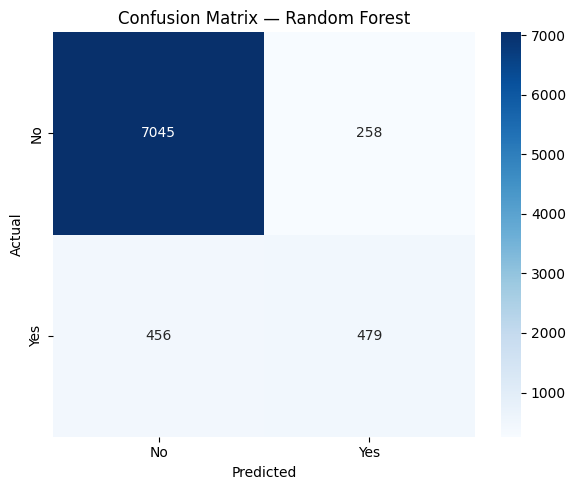

In [40]:
# Confusion Matrix — Random Forest
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


In [41]:
print("Classification Report — Random Forest:")
print(classification_report(y_test, rf_preds, target_names=['No','Yes']))


Classification Report — Random Forest:
              precision    recall  f1-score   support

          No       0.94      0.96      0.95      7303
         Yes       0.65      0.51      0.57       935

    accuracy                           0.91      8238
   macro avg       0.79      0.74      0.76      8238
weighted avg       0.91      0.91      0.91      8238



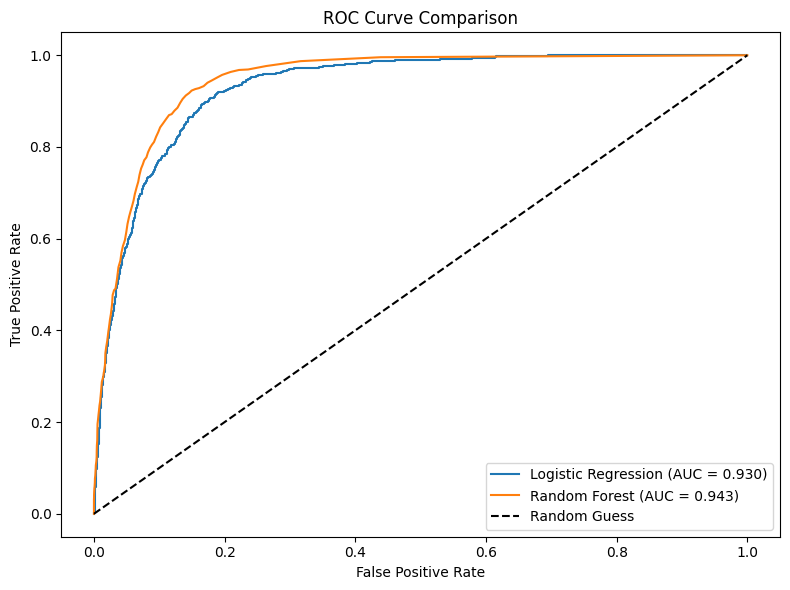

In [42]:
# ROC Curve — compares both models
# AUC (Area Under Curve): closer to 1.0 = better model
fig, ax = plt.subplots(figsize=(8,6))

for model, preds, name in [(lr, lr.predict_proba(X_test)[:,1], 'Logistic Regression'),
                            (rf, rf.predict_proba(X_test)[:,1], 'Random Forest')]:
    fpr, tpr, _ = roc_curve(y_test, preds)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', label='Random Guess')
ax.set_title('ROC Curve Comparison')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()


## 8: SHAP — Explaining Model Predictions

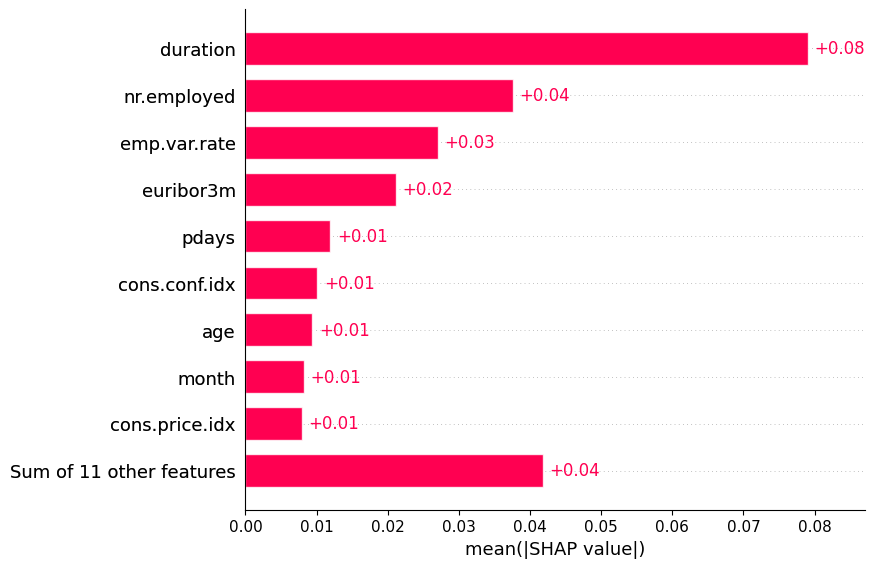

In [43]:
# SHAP explains why the model made a specific prediction
# It assigns each feature a value: positive = pushed toward 'yes', negative = pushed toward 'no'

# Sample 300 rows to keep it fast
X_sample = X_test.sample(300, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_sample)

# Select positive class (subscribed = yes)
shap_values_class1 = shap_values[..., 1]

# Global feature importance bar plot
shap.plots.bar(shap_values_class1, show=True)

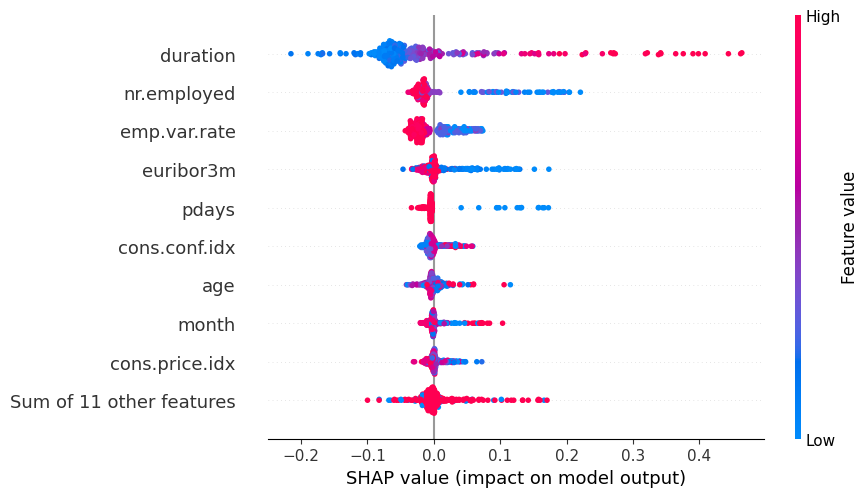

In [44]:
# Summary dot plot — shows direction of impact per feature
shap.plots.beeswarm(shap_values_class1, show=True)


Prediction explanation for sample 1:


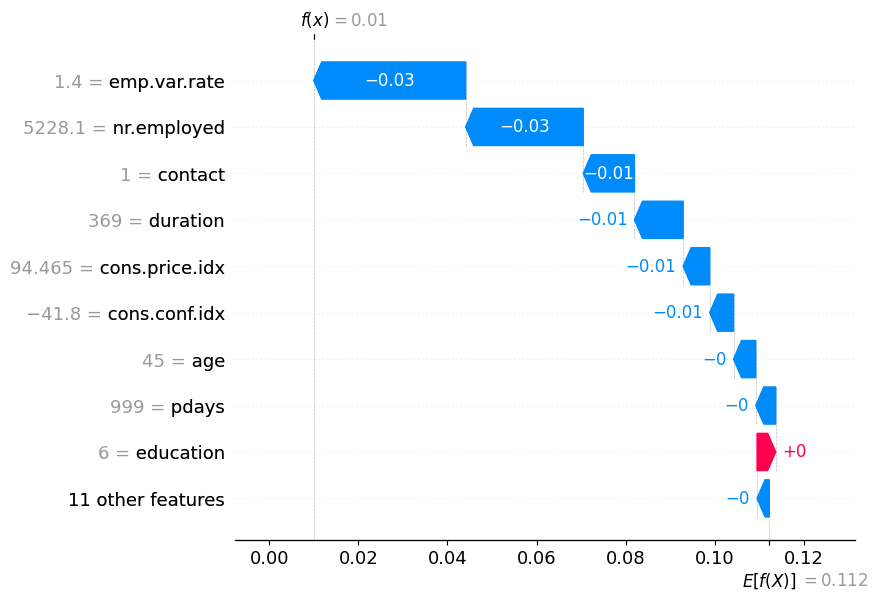


Prediction explanation for sample 2:


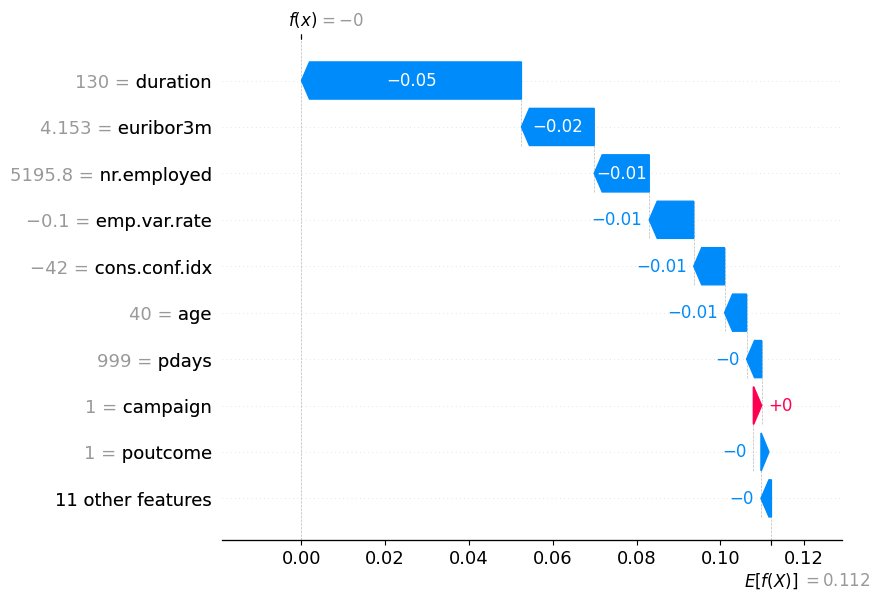


Prediction explanation for sample 3:


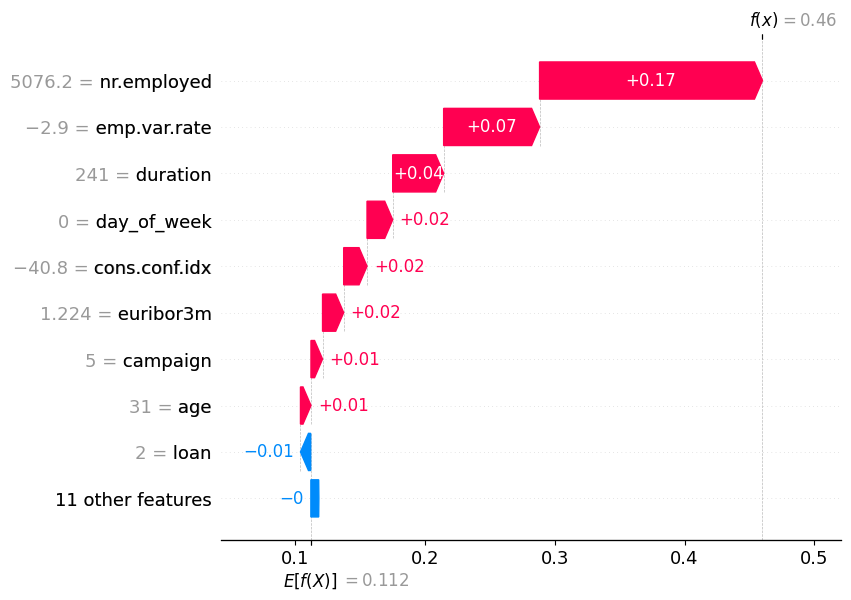


Prediction explanation for sample 4:


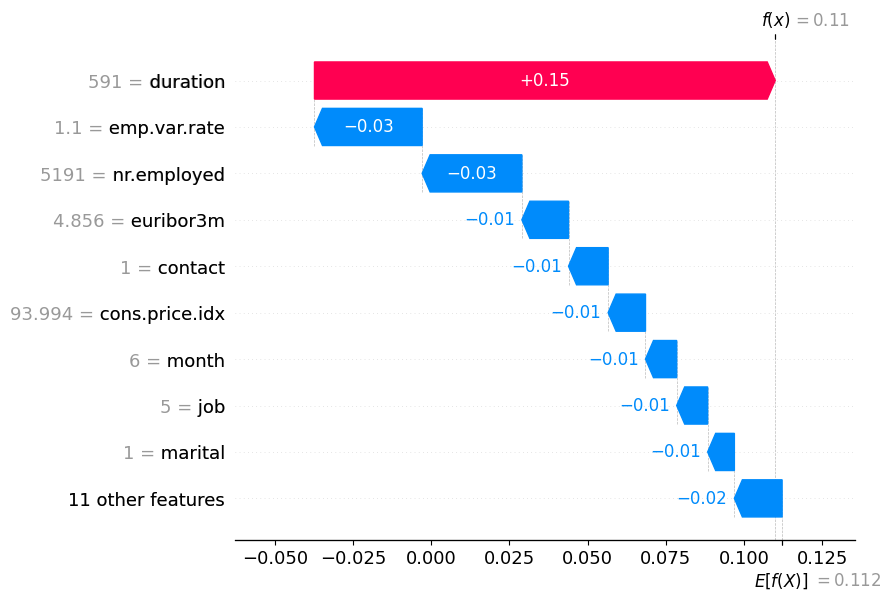


Prediction explanation for sample 5:


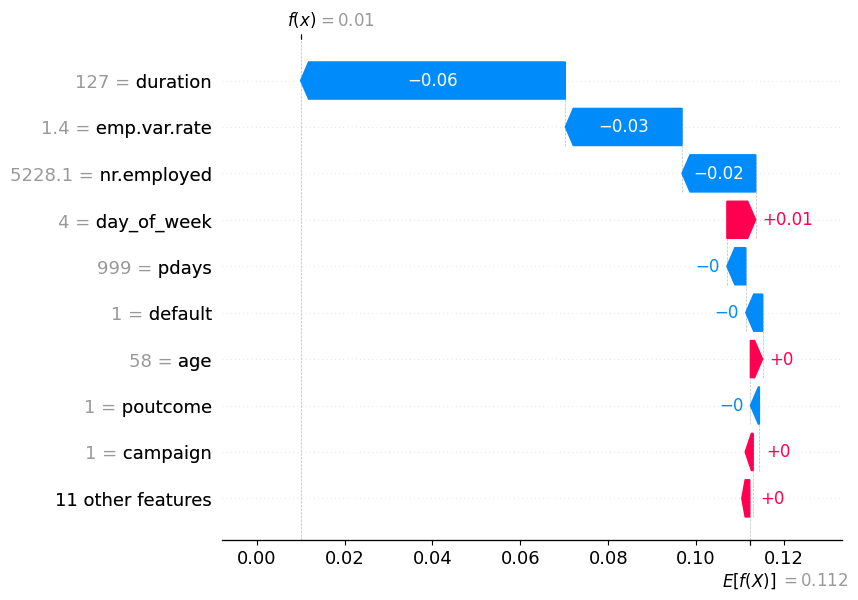

In [45]:
# Explain 5 individual predictions
for i in range(5):
    print(f"\nPrediction explanation for sample {i+1}:")
    shap.plots.waterfall(shap_values_class1[i], show=True)

## Conclusion

Key findings from Term Deposit Subscription Prediction:

1. **Class imbalance exists** — only ~11% of customers subscribed. This makes F1-score more important than accuracy alone.
2. **Random Forest outperforms Logistic Regression** — higher F1 and AUC score.
3. **Top predictors (from SHAP):** duration (call length), month of contact, balance, age, and job type.
4. **Call duration is the strongest signal** — longer calls strongly predict subscription. However, this is known only after the call, so it cannot be used to pre-select customers.
5. **Best months to call:** March, September, October, December show higher subscription rates.
6. **Business recommendation:** Target retired and student segments, contact in high-conversion months, and prioritize customers with higher bank balances.
